# 05 — Sonuç Analizi & Sunum Görselleri
6 deneyin metrik tablosu, ROC karşılaştırması ve sunum için grafikler.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from pathlib import Path

RESULTS_DIR = Path('../results')
FIGURES_DIR = RESULTS_DIR / 'figures'
METRICS_CSV = RESULTS_DIR / 'metrics.csv'

df = pd.read_csv(str(METRICS_CSV))
print(df.to_string(index=False))

     model preprocessing  accuracy  precision  recall     f1    auc
custom_cnn       minimal    0.8814     0.8641  0.9615 0.9102 0.9177
custom_cnn         clahe    0.8317     0.7950  0.9846 0.8797 0.9202
     vgg16       minimal    0.9119     0.8923  0.9769 0.9327 0.9756
     vgg16         clahe    0.9006     0.8850  0.9667 0.9240 0.9647
  resnet50       minimal    0.8750     0.8594  0.9564 0.9053 0.9453
  resnet50         clahe    0.8766     0.8598  0.9590 0.9067 0.9468


## 1. Metrik Karşılaştırma Tablosu (Isı Haritası)

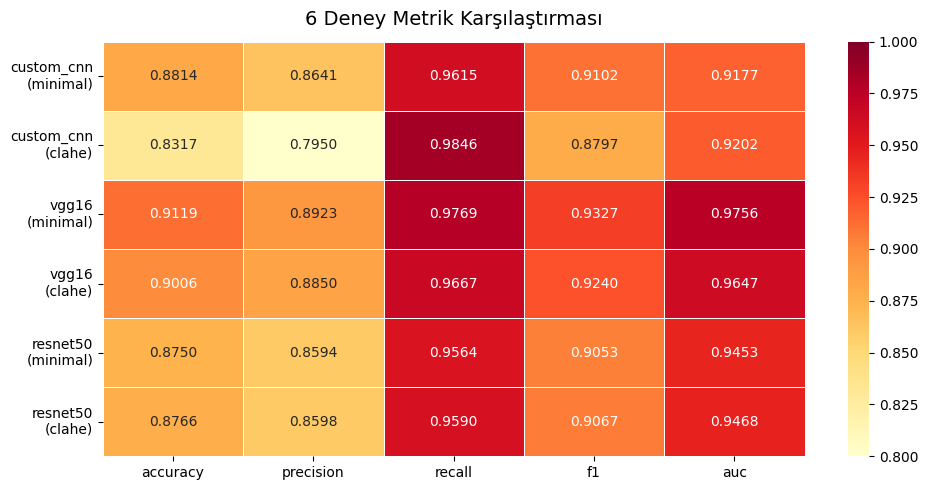

In [2]:
df['label'] = df['model'] + '\n(' + df['preprocessing'] + ')'
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc']
pivot = df.set_index('label')[metric_cols]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.80, vmax=1.00, linewidths=0.5, ax=ax)
ax.set_title('6 Deney Metrik Karşılaştırması', fontsize=14, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'metrics_heatmap.png'), dpi=150)
plt.show()

## 2. F1 ve AUC Çubuk Grafiği

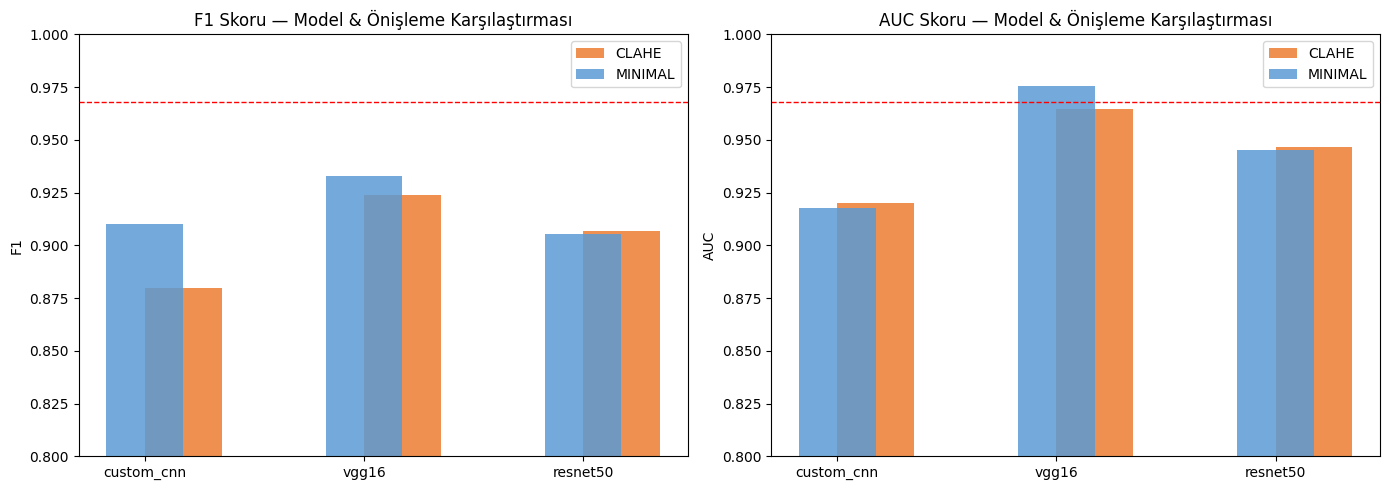

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'minimal': '#5B9BD5', 'clahe': '#ED7D31'}

for ax, metric in zip(axes, ['f1', 'auc']):
    for prep, grp in df.groupby('preprocessing'):
        ax.bar(grp['model'], grp[metric], label=prep.upper(),
               color=colors[prep], alpha=0.85, width=0.35,
               align='center' if prep=='minimal' else 'edge')
    ax.set_title(f'{metric.upper()} Skoru — Model & Önişleme Karşılaştırması')
    ax.set_ylabel(metric.upper())
    ax.set_ylim(0.80, 1.00)
    ax.legend()
    ax.axhline(0.968, color='red', linestyle='--', linewidth=1, label='Kermany 2018 AUC')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'f1_auc_comparison.png'), dpi=150)
plt.show()

## 3. Training Loss Eğrileri (Tüm Modeller Bir Arada)

Bulunan history dosyaları: []


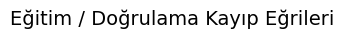

In [4]:
import glob

history_files = sorted(glob.glob(str(RESULTS_DIR / 'history_*.csv')))
print('Bulunan history dosyaları:', history_files)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, fpath in enumerate(history_files[:6]):
    name = Path(fpath).stem.replace('history_', '')
    hist_df = pd.read_csv(fpath)
    ax = axes[i]
    ax.plot(hist_df.get('loss', []), label='Train Loss')
    ax.plot(hist_df.get('val_loss', []), label='Val Loss')
    ax.set_title(name.replace('_', ' | '))
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)

for ax in axes[len(history_files):]:
    ax.set_visible(False)

plt.suptitle('Eğitim / Doğrulama Kayıp Eğrileri', fontsize=14)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'all_loss_curves.png'), dpi=150)
plt.show()

## 4. En İyi Model — Confusion Matrix

En iyi model: vgg16 | minimal — AUC: 0.9756


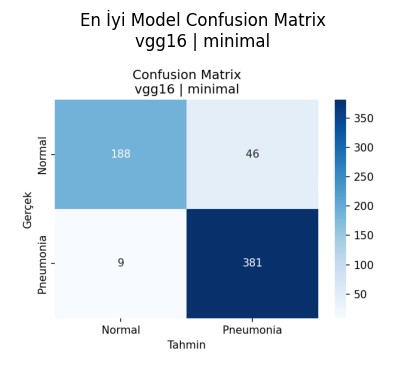

In [5]:
best_row = df.loc[df['auc'].idxmax()]
print(f"En iyi model: {best_row['model']} | {best_row['preprocessing']} — AUC: {best_row['auc']}")

cm_path = FIGURES_DIR / f"cm_{best_row['model']}_{best_row['preprocessing']}.png"
if cm_path.exists():
    from PIL import Image
    img = Image.open(str(cm_path))
    plt.figure(figsize=(5, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"En İyi Model Confusion Matrix\n{best_row['model']} | {best_row['preprocessing']}")
    plt.show()
else:
    print(f'Confusion matrix dosyası bulunamadı: {cm_path}')

## 5. CLAHE Etkisi Özeti

CLAHE Δ F1 (CLAHE - Minimal):
preprocessing  minimal   clahe  clahe_delta
model                                      
custom_cnn      0.9102  0.8797      -0.0305
resnet50        0.9053  0.9067       0.0014
vgg16           0.9327  0.9240      -0.0087


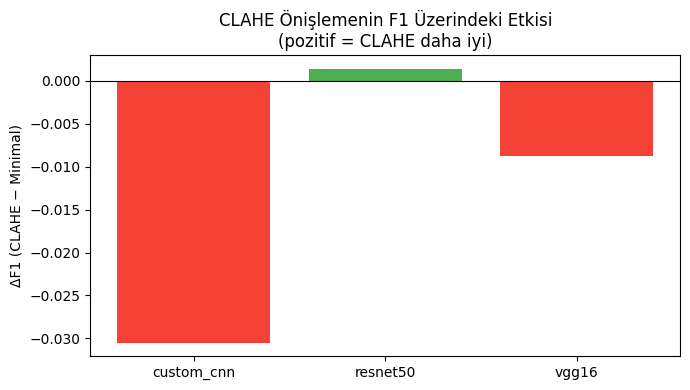

In [6]:
clahe_effect = df.pivot(index='model', columns='preprocessing', values='f1')
clahe_effect['clahe_delta'] = clahe_effect['clahe'] - clahe_effect['minimal']
print('CLAHE Δ F1 (CLAHE - Minimal):')
print(clahe_effect[['minimal', 'clahe', 'clahe_delta']].to_string())

fig, ax = plt.subplots(figsize=(7, 4))
colors_delta = ['#4CAF50' if v >= 0 else '#F44336' for v in clahe_effect['clahe_delta']]
ax.bar(clahe_effect.index, clahe_effect['clahe_delta'], color=colors_delta)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('CLAHE Önişlemenin F1 Üzerindeki Etkisi\n(pozitif = CLAHE daha iyi)')
ax.set_ylabel('ΔF1 (CLAHE − Minimal)')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'clahe_effect.png'), dpi=150)
plt.show()